# Hierarchical Agglomerative Clustering Dendrogram

Agglomerative hierarchical clustering groups coordinates bottom-up, sequentially merging the closest clusters based on linkage metrics. The hierarchical tree is visualized using a **dendrogram** (showing distance thresholds where merges occur). This notebook generates synthetic 2D consumer coordinates (250 observations), fits agglomerative clustering using Ward linkage, and plots the dendrogram using SciPy.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Generate synthetic 2D coordinate clusters (250 observations total)
# Centered around 4 clusters
np.random.seed(160)
n_samples = 250

centers = [
    [1.0, 1.0],
    [-1.0, 1.0],
    [1.0, -1.0],
    [-1.0, -1.0]
]

X_list = []
for center in centers:
    cluster_noise = np.random.normal(0, 0.35, (62, 2))
    X_list.append(center + cluster_noise)

# Append a few outliers to round to 250
X_list.append(np.random.uniform(-2, 2, (2, 2)))
X = np.vstack(X_list)

df_cluster = pd.DataFrame(X, columns=['Spend_Index', 'Visit_Frequency'])
df_cluster.head(10)



,Spend_Index,Visit_Frequency
0,0.826127,1.328309
1,0.472679,0.672416
2,1.618989,1.207561
3,0.861951,0.588126
4,1.375050,0.683793
5,0.790539,0.954424
6,0.298032,1.796425
7,0.941514,0.429787
8,1.008666,1.169838
9,1.108558,1.483235


## SciPy Linkage Matrix Computation

We calculate the hierarchical linkages using the Ward variance minimization algorithm.



In [2]:
# Calculate linkage matrix
Z = linkage(X, method='ward')

# Output linkage matrix shape (n_samples - 1 rows, 4 columns)
print(f"Agglomerative Linkage Matrix Dimensions: {Z.shape}")
print("First 5 merges:\n", Z[:5])



Agglomerative Linkage Matrix Dimensions: (249, 4)
First 5 merges:
 [[9.90000000e+01 1.11000000e+02 3.44862699e-03 2.00000000e+00]
 [1.43000000e+02 1.56000000e+02 6.82930383e-03 2.00000000e+00]
 [2.30000000e+02 2.33000000e+02 1.49745285e-02 2.00000000e+00]
 [2.34000000e+02 2.42000000e+02 1.52924704e-02 2.00000000e+00]
 [6.50000000e+01 1.06000000e+02 1.53117333e-02 2.00000000e+00]]


## Dendrogram Structure Plot

Using SciPy's dendrogram visualizer, we plot the merge sequence, coloring distinct cluster branches and drawing a threshold cutline at optimal height.



<cell>:22: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



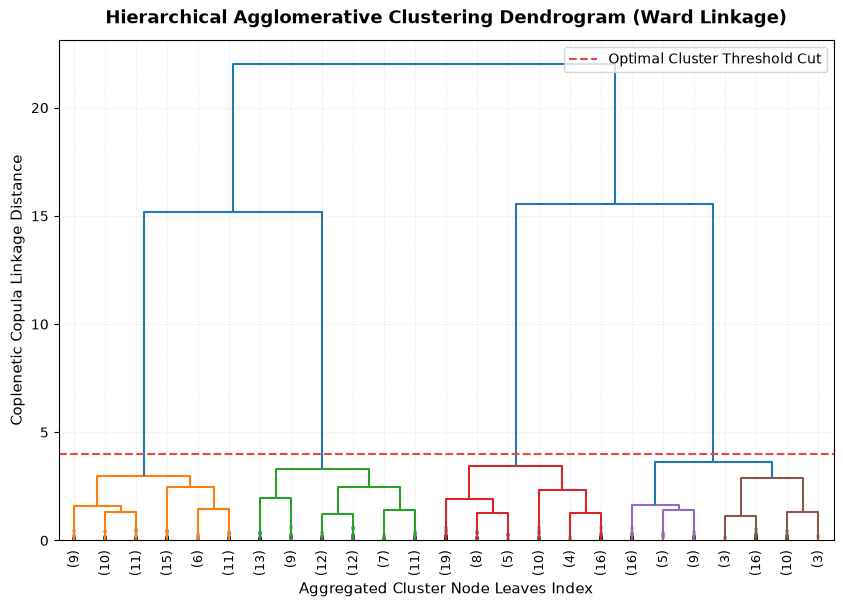

In [3]:
plt.figure(figsize=(10, 6.5))

# Draw dendrogram
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=25,                  # Show last 25 merges for clarity
    leaf_rotation=90.0,
    leaf_font_size=9.0,
    show_contracted=True,
    color_threshold=3.5     # Height threshold to color separate branches
)

# Draw cluster threshold line at height = 4.0 (yielding 4 clusters)
plt.axhline(4.0, color='#EF4444', linestyle='--', linewidth=1.5, label='Optimal Cluster Threshold Cut')

plt.title('Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Aggregated Cluster Node Leaves Index', fontsize=11)
plt.ylabel('Coplenetic Copula Linkage Distance', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()
